# Model Selection and Error Analysis for `difficulty_results_model_summary.csv`

This notebook does four things:
1. Loads the difficulty CV summary table.
2. Identifies the best model by accuracy, macro-F1, and MAE.
3. Rebuilds each selected configuration on the runner train/test split.
4. Shows per-rating accuracy, classification report, confusion matrices, and topic patterns for each metric leader.


In [1]:
import seaborn as sns
import rating_analysis_helpers as rah

sns.set_theme(style='whitegrid')

RESULTS_CSV = 'difficulty_results_model_summary.csv'
TARGET_COL = 'difficultyRating'

results, cv_summary = rah.load_results_tables(RESULTS_CSV)
metric_leaders = rah.select_metric_leaders(cv_summary)

print(f'Rows: {len(results)}')
print('Result types:', sorted(results['result_type'].dropna().unique().tolist()) if 'result_type' in results.columns else ['unknown'])
results.head()


Rows: 34
Result types: ['cv_summary']


,result_type,k,model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_mae,std_mae
0,cv_summary,10,hist_gradient_boosting,0.370736,0.003694,0.323376,0.003157,0.869579,0.006246
1,cv_summary,10,xgboost_cls,0.370033,0.003936,0.319312,0.003917,0.866482,0.006157
2,cv_summary,10,stacking_lsvc_logreg_rf,0.368656,0.003274,0.318488,0.003016,0.865229,0.005882
3,cv_summary,8,hist_gradient_boosting,0.367510,0.003056,0.317183,0.002573,0.875929,0.004795
4,cv_summary,8,xgboost_cls,0.367311,0.003811,0.314781,0.003191,0.872560,0.005285


In [2]:
print('Metric leaders from CV summary:')
display(metric_leaders[['selection_label', 'model', 'k', 'mean_accuracy', 'mean_macro_f1', 'mean_mae']])

print('Top 10 CV summary rows by accuracy ranking:')
display(cv_summary.sort_values(['mean_accuracy', 'mean_macro_f1', 'mean_mae'], ascending=[False, False, True])[['model', 'k', 'mean_accuracy', 'mean_macro_f1', 'mean_mae']].head(10))

test_rows = rah.get_optional_test_rows(results)
if test_rows.empty:
    print('No test row found in model summary CSV (expected when runner include_test_row=False).')
else:
    display(test_rows[[c for c in ['model', 'k', 'accuracy', 'macro_f1', 'mae'] if c in test_rows.columns]])


Metric leaders from CV summary:


,selection_label,model,k,mean_accuracy,mean_macro_f1,mean_mae
0,Best by Accuracy,hist_gradient_boosting,10,0.370736,0.323376,0.869579
1,Best by Macro-F1,random_forest_cls,10,0.348722,0.338558,0.978168
2,Best by MAE,stacking_lsvc_logreg_rf,10,0.368656,0.318488,0.865229


Top 10 CV summary rows by accuracy ranking:


,model,k,mean_accuracy,mean_macro_f1,mean_mae
0,hist_gradient_boosting,10,0.370736,0.323376,0.869579
1,xgboost_cls,10,0.370033,0.319312,0.866482
2,stacking_lsvc_logreg_rf,10,0.368656,0.318488,0.865229
3,hist_gradient_boosting,8,0.367510,0.317183,0.875929
4,xgboost_cls,8,0.367311,0.314781,0.872560
5,stacking_lsvc_logreg_rf,8,0.365853,0.314726,0.871452
6,bagging_linear,10,0.354562,0.273337,0.875301
7,multinomial_logreg,10,0.354549,0.273762,0.876115
8,ordinal_logistic,10,0.354258,0.278784,0.874859
9,hist_gradient_boosting,5,0.353398,0.277440,0.901170


No test row found in model summary CSV (expected when runner include_test_row=False).


## Rebuild and analyze each metric leader

The next cells reconstruct the same train/test split and feature pipeline used by the runner, then repeat the full downstream analysis for the best-by-accuracy, best-by-macro-F1, and best-by-MAE configurations.


In [3]:
state = rah.build_analysis_state(target_col=TARGET_COL)

print(f"Train rows: {len(state['df_train']):,}")
print(f"Test rows: {len(state['df_test']):,}")
print(f"Tag columns: {len(state['tag_cols'])}")


Train rows: 371,021
Test rows: 86,936
Tag columns: 27


## Best by Accuracy

Selected CV summary row:


,value
model,hist_gradient_boosting
k,10
mean_accuracy,0.370736
mean_macro_f1,0.323376
mean_mae,0.869579


Rebuilt model: hist_gradient_boosting (k=10)
Holdout accuracy: 0.3742
Holdout macro F1: 0.3272
Holdout MAE: 0.8691
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,10259,860,0.083829
1,2,18038,4260,0.236168
2,3,26221,16181,0.617101
3,4,19418,4605,0.237151
4,5,13000,6623,0.509462


Classification report:
              precision    recall  f1-score   support

           1     0.3383    0.0838    0.1344     10259
           2     0.3522    0.2362    0.2828     18038
           3     0.3619    0.6171    0.4563     26221
           4     0.3601    0.2372    0.2860     19418
           5     0.4474    0.5095    0.4764     13000

    accuracy                         0.3742     86936
   macro avg     0.3720    0.3367    0.3272     86936
weighted avg     0.3695    0.3742    0.3473     86936



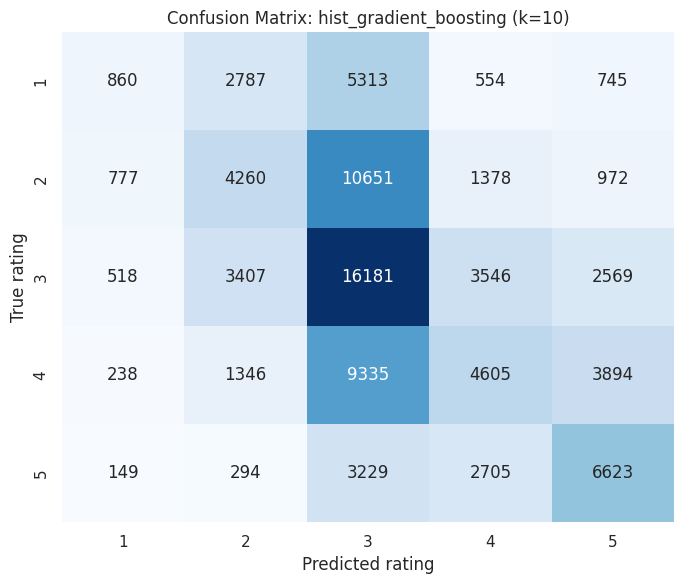

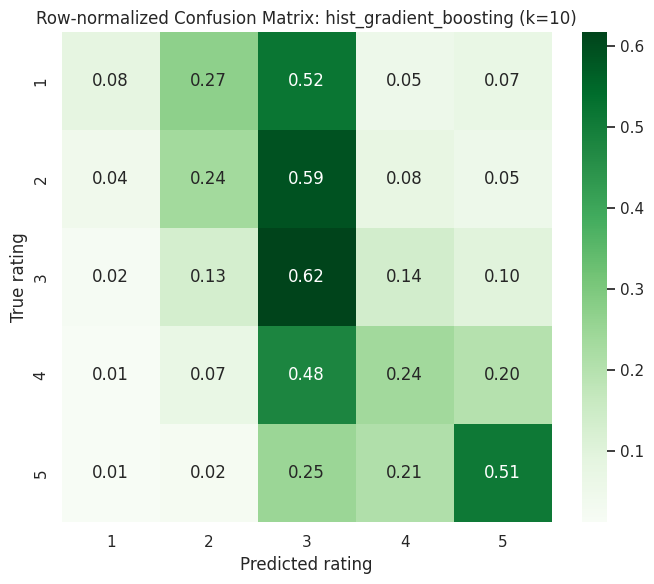

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,8,78700,3.589949,"class, don, like, just, time, know, teaching, ..."
1,0,57111,3.246853,"tests, lecture, lectures, exams, hard, questio..."
2,3,22825,3.228916,"office, hours, office hours, helpful, helpful ..."
3,6,23289,3.035124,"good, teacher, good teacher, good professor, r..."
4,1,31170,3.012993,"students, cares, cares students, really cares,..."
5,4,53520,2.985146,"final, midterm, midterm final, grade, quizzes,..."
6,2,24937,2.918314,"nice, guy, nice guy, really, really nice, funn..."
7,7,23253,2.796542,"best, best professor, professor, professors, b..."
8,9,23783,2.776984,"great, great professor, professor, great teach..."
9,5,32433,2.539851,"interesting, easy, class, recommend, fun, high..."


## Best by Macro-F1

Selected CV summary row:


,value
model,random_forest_cls
k,10
mean_accuracy,0.348722
mean_macro_f1,0.338558
mean_mae,0.978168


Rebuilt model: random_forest_cls (k=10)
Holdout accuracy: 0.3564
Holdout macro F1: 0.3451
Holdout MAE: 0.9630
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,10259,2421,0.235988
1,2,18038,5602,0.310567
2,3,26221,10538,0.401892
3,4,19418,4984,0.256669
4,5,13000,7440,0.572308


Classification report:
              precision    recall  f1-score   support

           1     0.2642    0.2360    0.2493     10259
           2     0.3258    0.3106    0.3180     18038
           3     0.3865    0.4019    0.3940     26221
           4     0.3347    0.2567    0.2905     19418
           5     0.4039    0.5723    0.4736     13000

    accuracy                         0.3564     86936
   macro avg     0.3430    0.3555    0.3451     86936
weighted avg     0.3505    0.3564    0.3500     86936



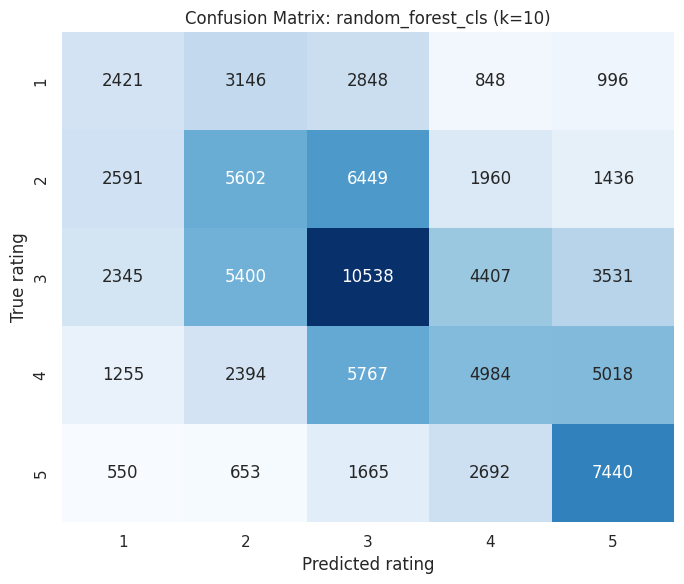

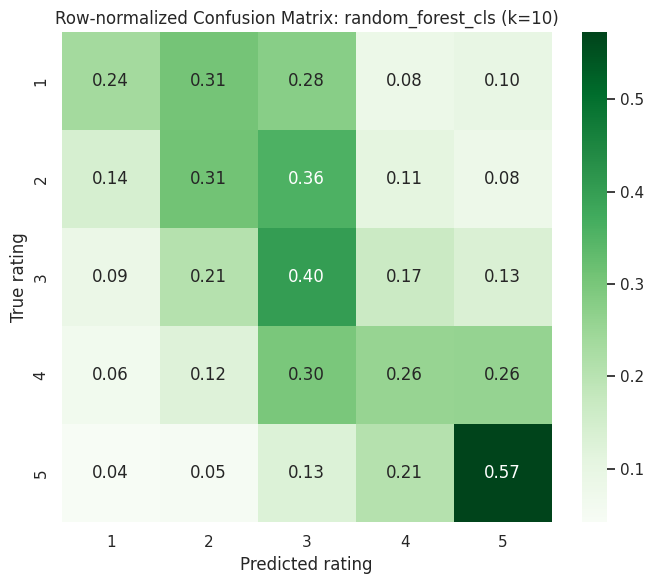

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,8,78700,3.589949,"class, don, like, just, time, know, teaching, ..."
1,0,57111,3.246853,"tests, lecture, lectures, exams, hard, questio..."
2,3,22825,3.228916,"office, hours, office hours, helpful, helpful ..."
3,6,23289,3.035124,"good, teacher, good teacher, good professor, r..."
4,1,31170,3.012993,"students, cares, cares students, really cares,..."
5,4,53520,2.985146,"final, midterm, midterm final, grade, quizzes,..."
6,2,24937,2.918314,"nice, guy, nice guy, really, really nice, funn..."
7,7,23253,2.796542,"best, best professor, professor, professors, b..."
8,9,23783,2.776984,"great, great professor, professor, great teach..."
9,5,32433,2.539851,"interesting, easy, class, recommend, fun, high..."


## Best by MAE

Selected CV summary row:


,value
model,stacking_lsvc_logreg_rf
k,10
mean_accuracy,0.368656
mean_macro_f1,0.318488
mean_mae,0.865229


/home/leofukunaga/vscodestuff/python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/leofukunaga/vscodestuff/python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/leofukunaga/vscodestuff/python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/leofukunaga/vscodestuff/python/.venv/lib/py

Rebuilt model: stacking_lsvc_logreg_rf (k=10)
Holdout accuracy: 0.3734
Holdout macro F1: 0.3255
Holdout MAE: 0.8618
Per-rating accuracy (conditioned on true class):


,true_rating,support,correct_predictions,accuracy_when_true
0,1,10259,855,0.083341
1,2,18038,4385,0.243098
2,3,26221,16542,0.630868
3,4,19418,4318,0.222371
4,5,13000,6366,0.489692


Classification report:
              precision    recall  f1-score   support

           1     0.3420    0.0833    0.1340     10259
           2     0.3517    0.2431    0.2875     18038
           3     0.3579    0.6309    0.4567     26221
           4     0.3651    0.2224    0.2764     19418
           5     0.4572    0.4897    0.4729     13000

    accuracy                         0.3734     86936
   macro avg     0.3748    0.3339    0.3255     86936
weighted avg     0.3712    0.3734    0.3457     86936



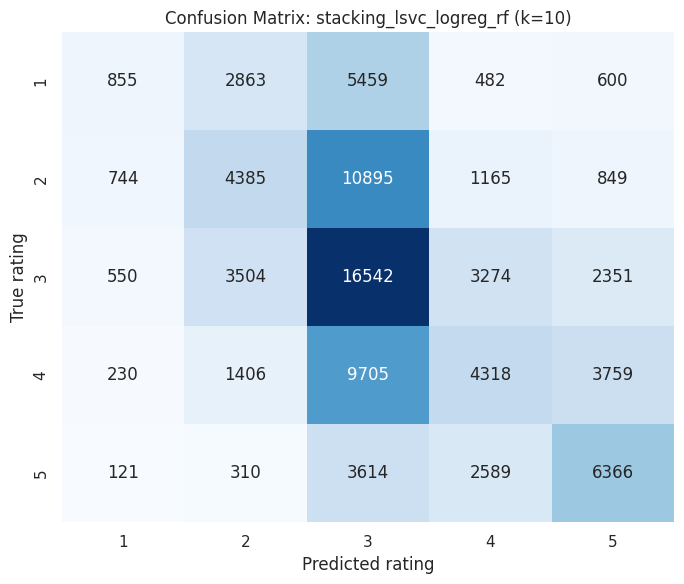

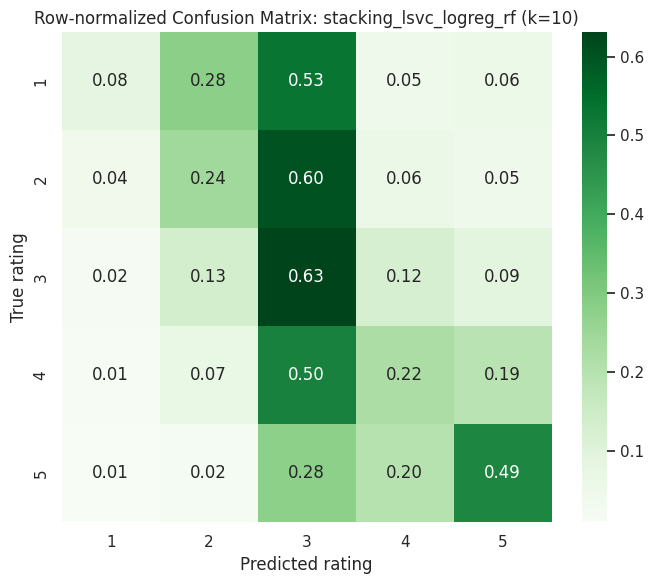

Topic-level descriptive patterns:


,topic,support,mean_rating,top_words
0,8,78700,3.589949,"class, don, like, just, time, know, teaching, ..."
1,0,57111,3.246853,"tests, lecture, lectures, exams, hard, questio..."
2,3,22825,3.228916,"office, hours, office hours, helpful, helpful ..."
3,6,23289,3.035124,"good, teacher, good teacher, good professor, r..."
4,1,31170,3.012993,"students, cares, cares students, really cares,..."
5,4,53520,2.985146,"final, midterm, midterm final, grade, quizzes,..."
6,2,24937,2.918314,"nice, guy, nice guy, really, really nice, funn..."
7,7,23253,2.796542,"best, best professor, professor, professors, b..."
8,9,23783,2.776984,"great, great professor, professor, great teach..."
9,5,32433,2.539851,"interesting, easy, class, recommend, fun, high..."


In [4]:
analysis_results = rah.run_metric_leader_analysis(metric_leaders, state)
